# Dataset Exploration: Moltbook vs. Reddit

This notebook provides an interactive environment to load the parsed NetworkX graphs for both platforms and run basic statistical analyses.

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Import our loading functions
from utils import load_moltbook_graph, load_reddit_graph, get_platform_colors

plt.style.use('default')
plt.rcParams.update({'font.size': 16})

c:\Users\malda\anaconda3\envs\moltbook_rf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the Datasets

This cell will parse the Hugging Face datasets and build the NetworkX `DiGraph` objects if they haven't been cached already. (Note: The first run may take a little while for Reddit depending on the `limit` parameter, but subsequent runs will load instantly from the `.pkl` caches).

In [ ]:
# Load Moltbook
print("Loading Moltbook Graph...")
G_moltbook = load_moltbook_graph(cache=True)
print(f"Moltbook Nodes: {G_moltbook.number_of_nodes():,}")
print(f"Moltbook Edges: {G_moltbook.number_of_edges():,}\n")

# Load Reddit
print("Loading Reddit Graph...")
G_reddit = load_reddit_graph(cache=True, limit=250000)
print(f"Reddit Nodes: {G_reddit.number_of_nodes():,}")
print(f"Reddit Edges: {G_reddit.number_of_edges():,}")

2026-05-04 13:48:02,366 - INFO - Building Moltbook graph from Hugging Face dataset...


Loading Moltbook Graph...


2026-05-04 13:48:02,654 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-05-04 13:48:02,656 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-04 13:48:02,681 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/SimulaMet/moltbook-observatory-archive/1fe74c52787f2699c3b80029a3c35a50c6d0e0ca/README.md "HTTP/1.1 200 OK"
2026-05-04 13:48:02,858 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive/resolve/1fe74c52787f2699c3b80029a3c35a50c6d0e0ca/moltbook-observatory-archive.py "HTTP/1.1 404 Not Found"
2026-05-04 13:48:03,066 - INFO - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/SimulaMet/moltbook-observatory-archive/SimulaMet/moltbook-observatory-archive.py "HTTP/1

## 2. Degree Distribution Analysis

Social networks typically follow a power-law (heavy-tailed) degree distribution. Let's visualize the differences between Moltbook (Social Graph) and Reddit (Interest Graph).

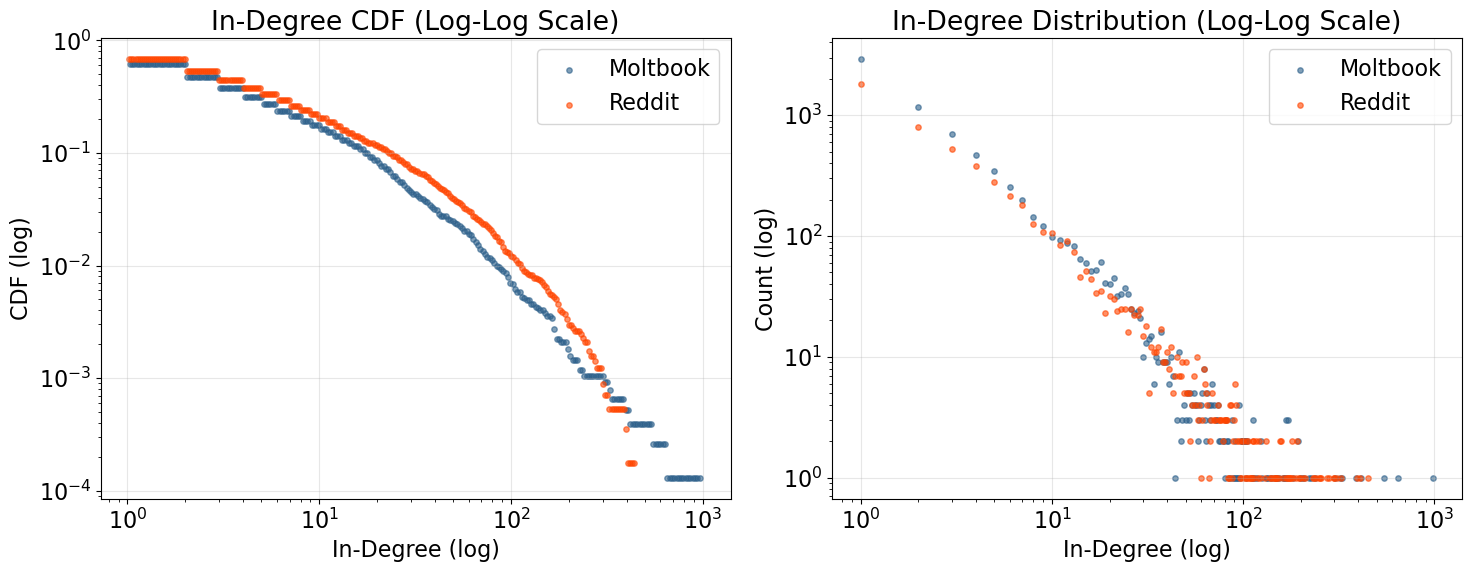

In [ ]:
def plot_degree_dist(G_m, G_r, degree='in'):
    colors = get_platform_colors()
    
    if degree == 'in':
        m_deg = np.array([d for n, d in G_m.in_degree() if d > 0])
        r_deg = np.array([d for n, d in G_r.in_degree() if d > 0])
    elif degree == 'out':
        m_deg = np.array([d for n, d in G_m.out_degree() if d > 0])
        r_deg = np.array([d for n, d in G_r.out_degree() if d > 0])
    
    # Log-Log Plot (better for power-law analysis)
    m_counts = Counter(m_deg)
    r_counts = Counter(r_deg)

    # get CDF of weighted degree for better visualization
    rm_bins = np.logspace(np.log10(m_deg.min()), np.log10(m_deg.max()), 250)
    rr_bins = np.logspace(np.log10(r_deg.min()), np.log10(r_deg.max()), 250)

    mcounts, mbins = np.histogram(m_deg, bins=rm_bins)
    rcounts, rbins = np.histogram(r_deg, bins=rr_bins)

    mcdf = np.cumsum(mcounts) / sum(mcounts)
    rcdf = np.cumsum(rcounts) / sum(rcounts)
    

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.scatter(mbins[1:], 1 - mcdf, 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax1.scatter(rbins[1:], 1 - rcdf, 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    if degree == 'in':
        ax1.set_title('In-Degree CDF (Log-Log Scale)')
        ax1.set_xlabel('In-Degree (log)')
        ax1.set_ylabel('CDF (log)')
    elif degree == 'out':
        ax1.set_title('Out-Degree CDF (Log-Log Scale)')
        ax1.set_xlabel('Out-Degree (log)')
        ax1.set_ylabel('CDF (log)')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    
    ax2.scatter(list(m_counts.keys()), list(m_counts.values()), 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax2.scatter(list(r_counts.keys()), list(r_counts.values()), 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    if degree == 'in':
        ax2.set_title('In-Degree Distribution (Log-Log Scale)')
        ax2.set_xlabel('In-Degree (log)')
        ax2.set_ylabel('Count (log)')
    elif degree == 'out':
        ax2.set_title('Out-Degree Distribution (Log-Log Scale)')
        ax2.set_xlabel('Out-Degree (log)')
        ax2.set_ylabel('Count (log)')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_degree_dist(G_moltbook, G_reddit, degree='in')
plot_degree_dist(G_moltbook, G_reddit, degree='out')

## 3. Global Graph Level Statistics

The structure of a global graph can be characterized by a variety of statistics. Here, we assemble a bar chart comparing Assortativity, Avg Clustering, Density, and Reciprocity between Moltbook and Reddit.

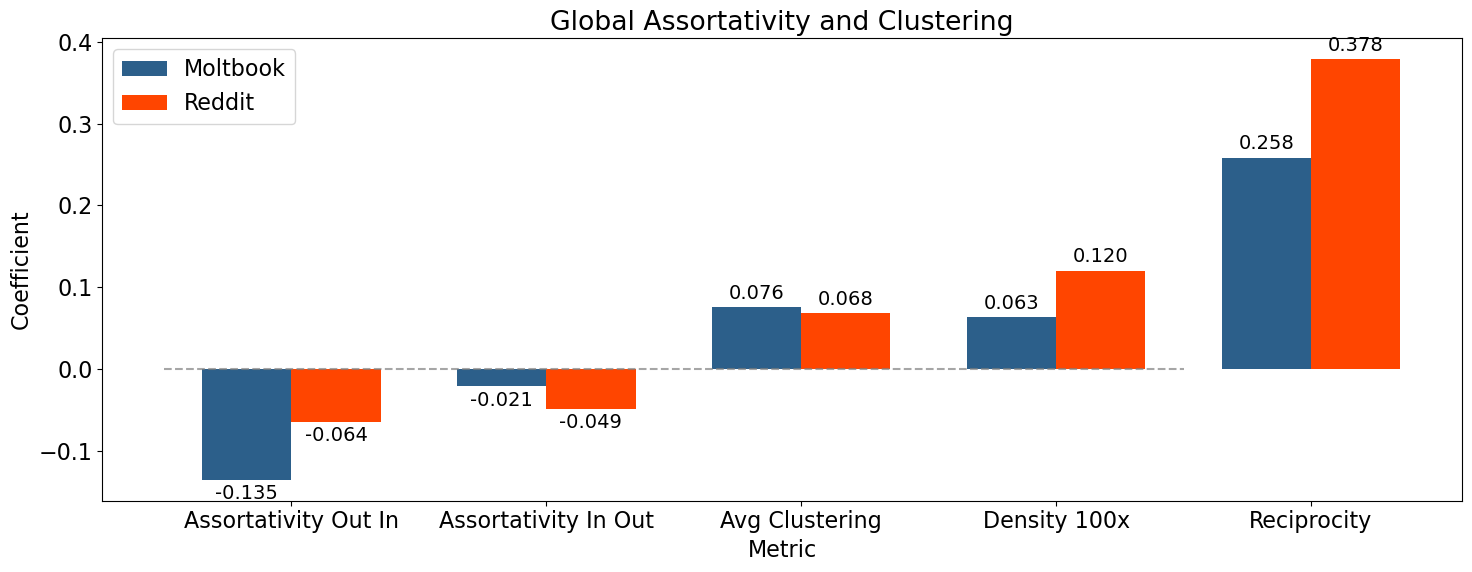

In [ ]:
def plot_assortativity_clustering(G_m, G_r, radius=2):

    # Bar Plot metrics: Assortativity and Average Clustering
    metrics = {
        'Assortativity Out In': {
            'Moltbook': nx.degree_assortativity_coefficient(G_m),
            'Reddit': nx.degree_assortativity_coefficient(G_r)
        },
        'Assortativity In Out': {
            'Moltbook': nx.degree_assortativity_coefficient(G_m, 'in', 'out'),
            'Reddit': nx.degree_assortativity_coefficient(G_r, 'in', 'out')
        },
        'Avg Clustering': {
            'Moltbook': nx.average_clustering(G_m),
            'Reddit': nx.average_clustering(G_r)
        },
        'Density 100x' : {
            'Moltbook': nx.density(G_m) * 100,
            'Reddit': nx.density(G_r) * 100,
        },
        'Reciprocity': {
            'Moltbook': nx.reciprocity(G_m),
            'Reddit': nx.reciprocity(G_r),
        }
    }

    # Clustering distribution
    clust_dist_m = np.array(list(nx.clustering(G_m).values()))
    clust_dist_r = np.array(list(nx.clustering(G_r).values()))
    clust_dist_m = clust_dist_m[clust_dist_m > 0]
    clust_dist_r = clust_dist_r[clust_dist_r > 0]

    colors = get_platform_colors()

    # Generate figure
    fig, (ax1) = plt.subplots(1, 1, figsize=(15, 6))

    x = np.arange(len(metrics))
    width = 0.35
    
    # Put metrics in list for each platform
    m_values = [
                    metrics['Assortativity Out In']['Moltbook'], metrics['Assortativity In Out']['Moltbook'], metrics['Avg Clustering']['Moltbook'], 
                    metrics['Density 100x']['Moltbook'], metrics['Reciprocity']['Moltbook']
                ]
    r_values = [
                    metrics['Assortativity Out In']['Reddit'], metrics['Assortativity In Out']['Reddit'], metrics['Avg Clustering']['Reddit'], 
                    metrics['Density 100x']['Reddit'], metrics['Reciprocity']['Reddit']
                ]

    # plot metrics with bar widths/heights
    rects1 = ax1.bar(x - width/2, m_values, width, label='Moltbook', color=colors['Moltbook'])
    rects2 = ax1.bar(x + width/2, r_values, width, label='Reddit', color=colors['Reddit'])
    ax1.hlines(0, -0.5, 3.5, colors='gray', linestyles='dashed', alpha=0.7)

    # set tick labels to metric names
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics.keys())
    ax1.bar_label(rects1, padding=3, fmt='%.3f', fontsize=14)
    ax1.bar_label(rects2, padding=3, fmt='%.3f', fontsize=14)
    
    ax1.set_title('Global Assortativity and Clustering')
    ax1.set_xlabel('Metric')
    ax1.set_ylabel('Coefficient')
    ax1.legend()
    
    plt.tight_layout()
    plt.show()

plot_assortativity_clustering(G_moltbook, G_reddit)

## 4. Time Evolution Moltbook Statistics

Given that Moltbook is a newer forum, the graph level statistics are still reaching their equilibrium. To see how Moltbook is evolving, we plot cumulative statistics over time. The following cell will download and build cumulative graphs of Moltbook. We generate a new graph each "window_days." E.g. If our graph spans 15 days, and we select a 3 day window, we will generate 5 graphs where each graph is the global network snapshotted at the end of each 3 dasy window.

In [ ]:
from utils import load_temporal_moltbook_graph

temporal_mgraphs = load_temporal_moltbook_graph(window_days=3, cache=True)

Cumulative Statistics


c:\Users\malda\anaconda3\envs\moltbook_rf\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


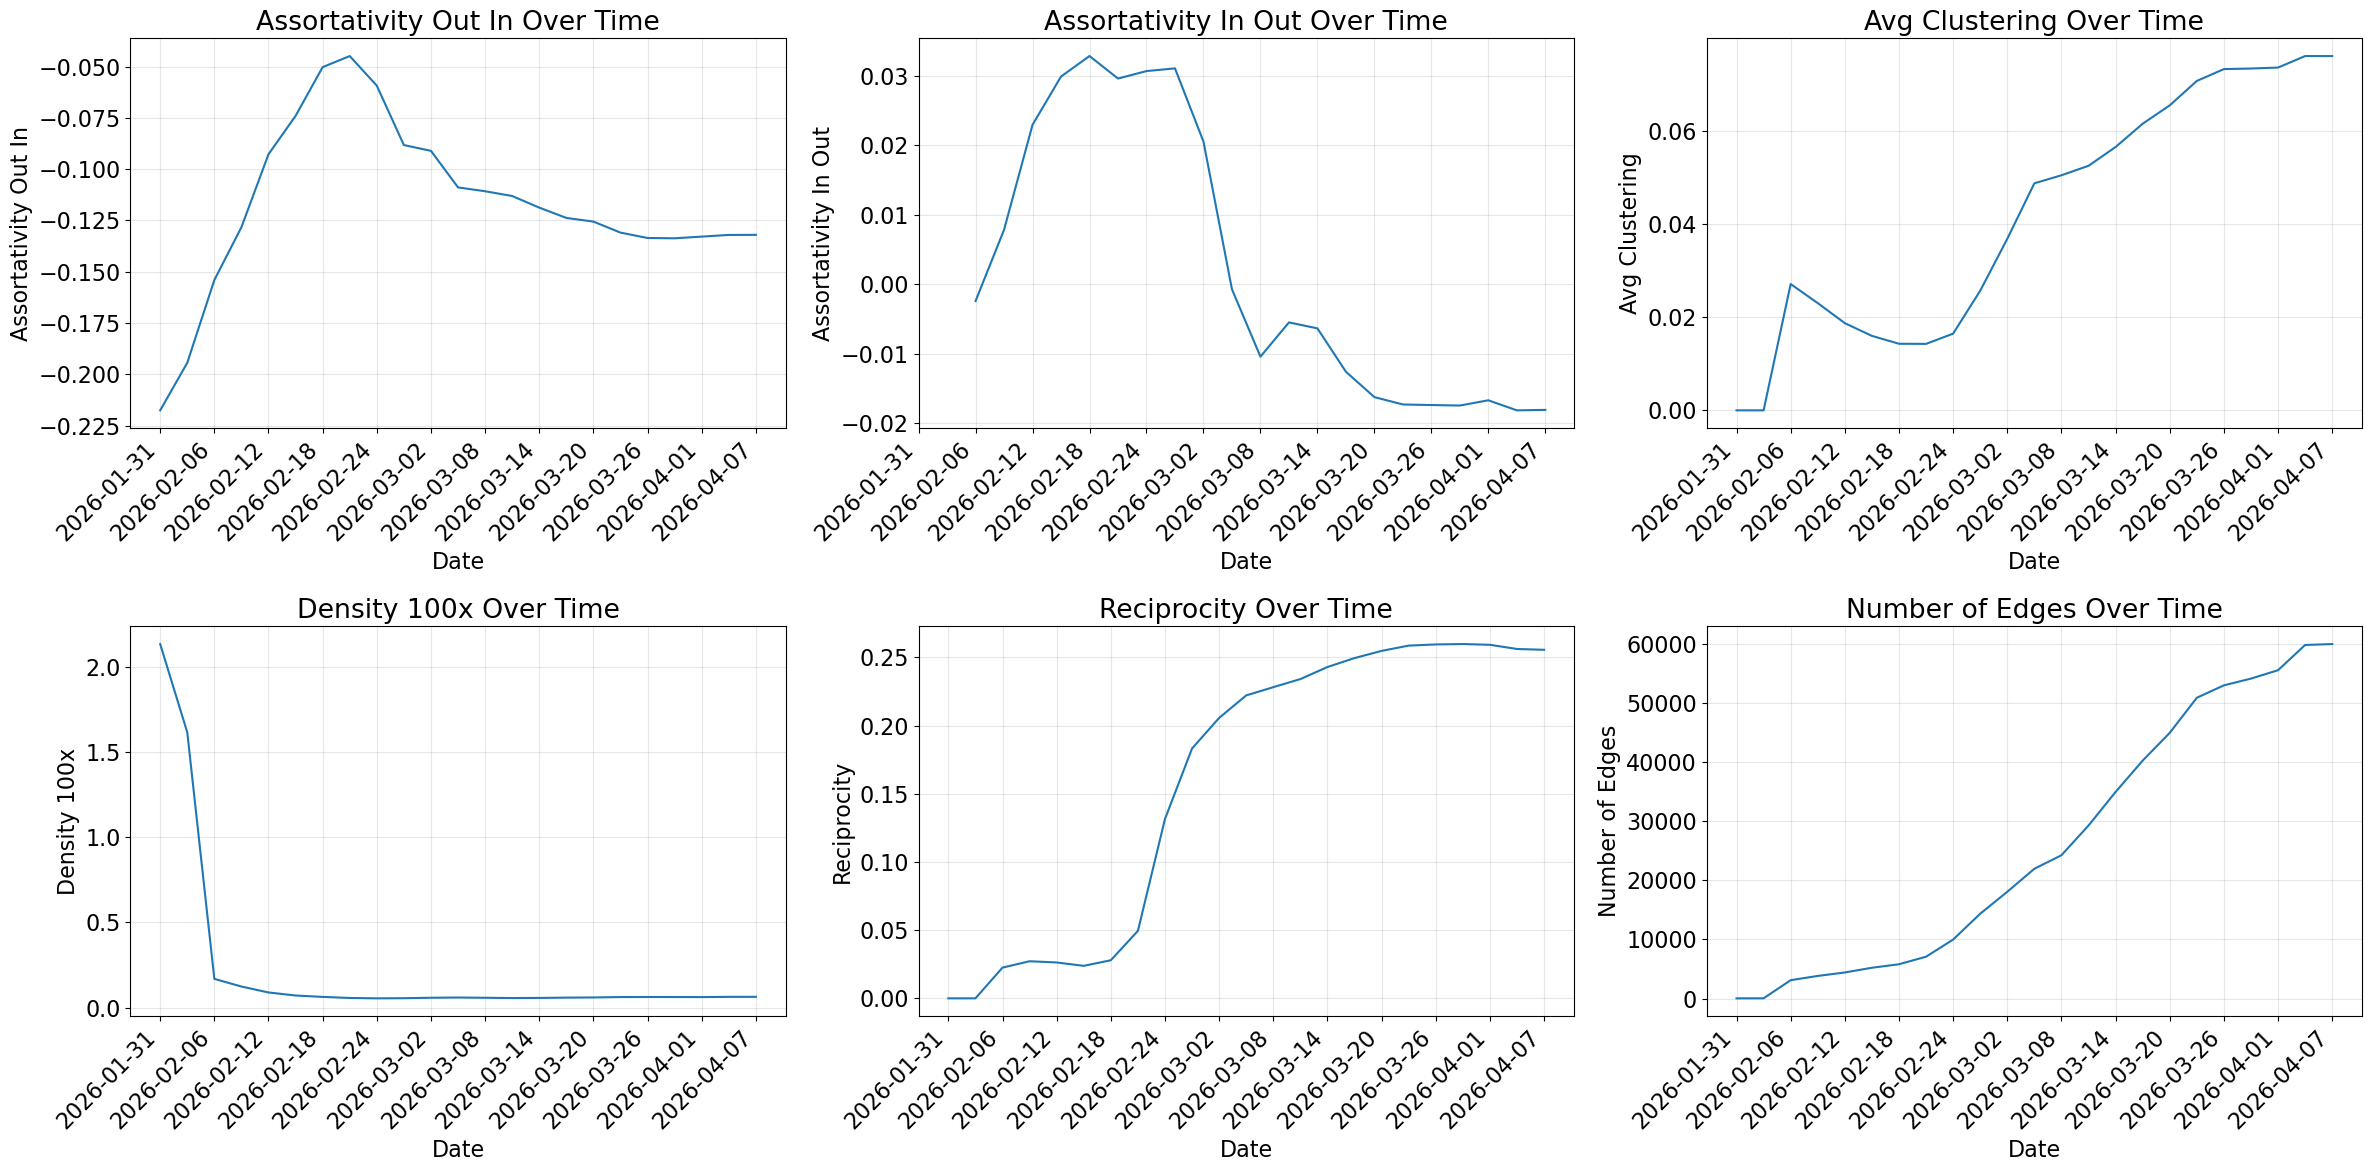

Windowed Statistics


c:\Users\malda\anaconda3\envs\moltbook_rf\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


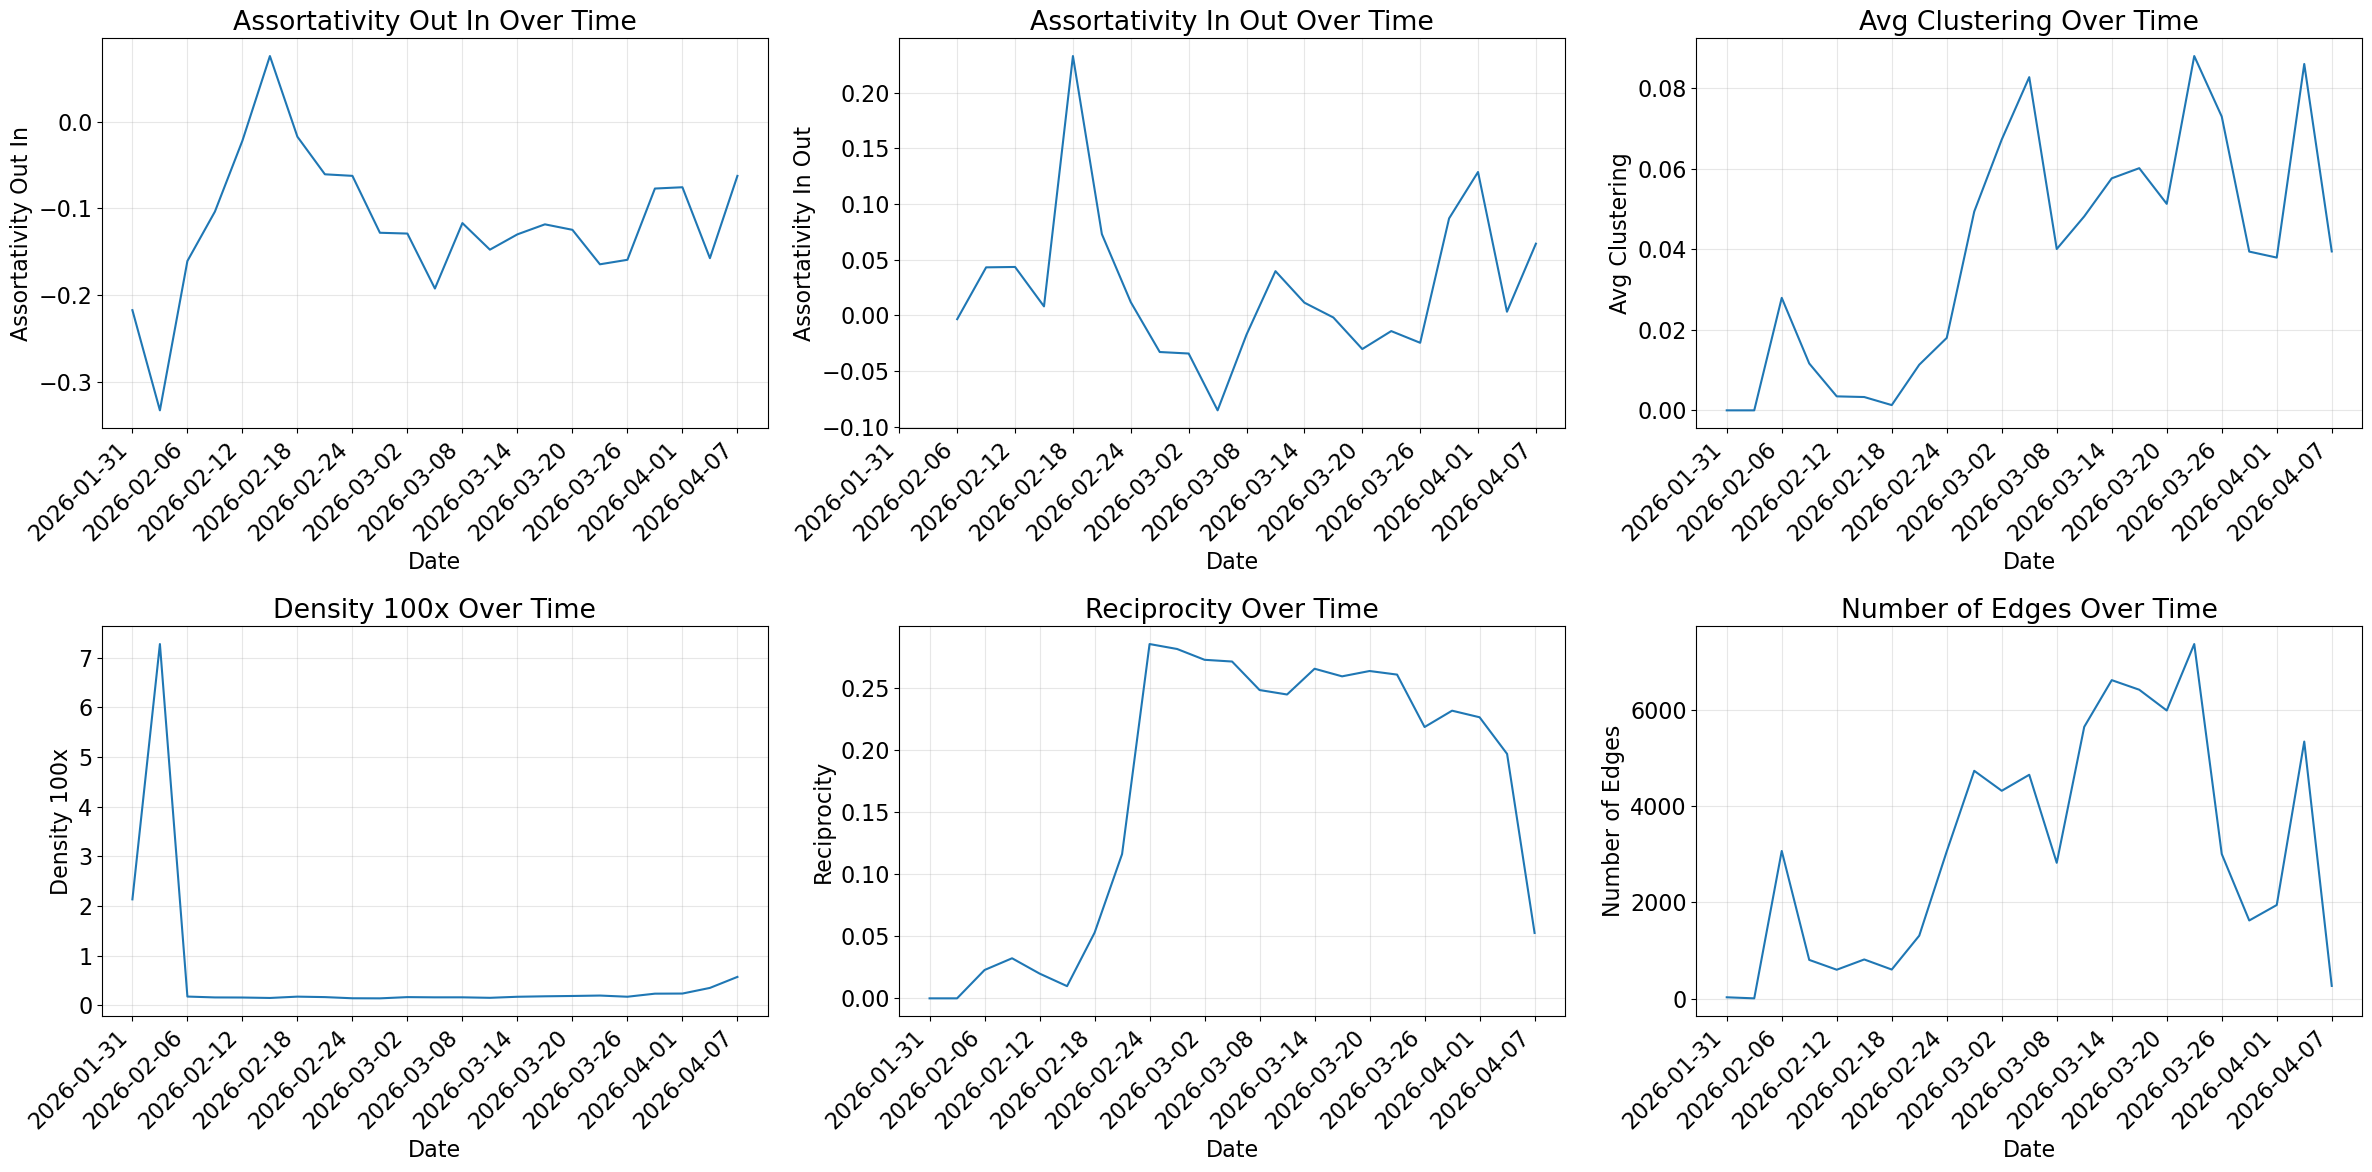

In [ ]:
def plot_time_evolved_stats(time_graphs, window=False):

    # Bar Plot metrics: Assortativity and Average Clustering
    metrics = {
        'Assortativity Out In': [],
        'Assortativity In Out': [],
        'Avg Clustering': [],
        'Density 100x' : [],
        'Reciprocity': [],
        'Number of Edges': []
    }

    graph_key = 'graph_cumulative'
    if window:
        graph_key = 'graph_window'

    time_x = []
    for graph_inst in time_graphs:
        period = graph_inst['date']
        graph = graph_inst[graph_key]
        metrics['Assortativity Out In'].append(nx.degree_assortativity_coefficient(graph, 'out', 'in'))
        metrics['Assortativity In Out'].append(nx.degree_assortativity_coefficient(graph, 'in', 'out'))
        metrics['Avg Clustering'].append(nx.average_clustering(graph))
        metrics['Density 100x'].append(nx.density(graph) * 100)
        metrics['Reciprocity'].append(nx.reciprocity(graph))
        metrics['Number of Edges'].append(graph.number_of_edges())
        time_x.append(period)

    # Generate figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

    for i, metric_key in enumerate(metrics.keys()):
        row = i // 3
        col = i % 3
        ax = axes[row, col]

        ax.plot(time_x, metrics[metric_key], linewidth=2.5)
        
        ax.set_title(f'{metric_key} Over Time')
        ax.set_ylabel(metric_key)
        ax.tick_params(axis='both', which='major', labelsize=14)

        ax.grid(True, alpha=0.3)
    
    # Format the X-axis ONLY on the bottom row to prevent top-row clutter
    for ax in axes[1, :]:
        ax.set_xlabel('Date', fontsize=18, labelpad=10)
        ax.set_xticks(time_x[::2])
        ax.set_xticklabels([t.strftime('%Y-%m-%d') for t in time_x[::2]], rotation=45, ha='right')

    
    plt.tight_layout()
    plt.show()

print('Cumulative Statistics')
plot_time_evolved_stats(time_graphs=temporal_mgraphs, window=False)